# IMDb Movie Chatbot — Case Study 2 (Part 1)

**Full Name:** Wei Wong  
**Uplevel Email Address:** `shihwei.wong@gmail.com`  
**Problem Statement:** IMDb Movie Chatbot — Conversational movie search and recommendations

> This section focuses on Part 1 only: data understanding, cleaning decisions, EDA, and retrieval-ready feature prep.


## Project Overview

This case study positions the IMDb chatbot as an **AI-powered content discovery product** rather than a simple question-answering bot. The goal is to help users move from vague intent or fragmented preferences to confident movie choices through natural conversation, relevant retrieval, and clear recommendation reasoning.

**Business Objective:** Build a conversational movie discovery assistant that reduces search friction, improves recommendation quality, and increases user engagement by helping people find the right title faster and with more confidence.

This framing matters for employers because the same product pattern applies to platforms such as Netflix, Spotify, YouTube, and e-commerce marketplaces: combine semantic retrieval, personalization, and strong user experience to improve discovery, retention, and user trust.

In this notebook, Part 1 focuses on creating the data foundation for that product: understanding the dataset, making explicit cleaning decisions, and preparing retrieval-ready features that support better recommendations and more engaging conversations in Part 2.

## Part 1 Objectives (Grading-First)

1. Understand the dataset shape, schema, and quality risks.
2. Make explicit, reproducible cleaning decisions (especially duplicates).
3. Build a reliable `clean_df` with `movie_id` and `search_text` for Part 2 embeddings/FAISS.
4. Document insights that matter for product behavior and retrieval quality.


In [7]:
# We centralize imports and plotting defaults so every later cell is concise and reproducible.
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


In [8]:
# Loading from an explicit path removes ambiguity during grading and reruns.
DATASET_PATH = Path("/Users/weiwong/Documents/personal/projects/courses/2025-09-ik-ml-engineering/2026-03-08-case-study-2-imdb/imdb_dataset.csv")

# Fallback keeps the notebook runnable if the absolute path changes (e.g., Colab/local copy).
if not DATASET_PATH.exists():
    DATASET_PATH = Path("imdb_dataset.csv")

raw_df = pd.read_csv(DATASET_PATH)
print(f"Loaded dataset from: {DATASET_PATH.resolve()}")
print(f"Shape: {raw_df.shape}")
raw_df.head(3)


Loaded dataset from: /Users/weiwong/Documents/personal/projects/courses/2025-09-ik-ml-engineering/2026-03-08-case-study-2-imdb/imdb_dataset.csv
Shape: (3173, 10)


,Title,IMDb Rating,Year,Certificates,Genre,Director,Star Cast,MetaScore,Poster-src,Duration (minutes)
0,End of the Spear,6.8,2005,PG-13,Adventure,Jim Hanon,Louie LeonardoChad AllenJack Guzman,45.0,https://m.media-amazon.com/images/M/MV5BMTYxOT...,108.0
1,Elvira Madigan,7.0,1967,PG,Biography,Bo Widerberg,Pia DegermarkThommy BerggrenLennart Malmer,66.0,https://m.media-amazon.com/images/M/MV5BMmY2Nj...,91.0
2,The Kid Stays in the Picture,7.3,2002,R,Documentary,Nanette Burstein,Robert EvansEddie AlbertPeter Bart,75.0,https://m.media-amazon.com/images/M/MV5BZjhiZm...,93.0


In [9]:
# We create a one-glance quality dashboard to guide cleaning decisions before modeling.
def build_data_quality_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    """Return a compact quality table so decisions are explicit and reviewable."""
    cast_has_delimiter = df["Star Cast"].astype(str).str.contains(r",|\||;", regex=True, na=False)
    snapshot = {
        "rows": len(df),
        "columns": df.shape[1],
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "duplicate_titles": int(df.duplicated(subset=["Title"]).sum()),
        "duplicate_title_year": int(df.duplicated(subset=["Title", "Year"]).sum()),
        "year_range": f"{df['Year'].min()} to {df['Year'].max()}",
        "imdb_rating_range": f"{df['IMDb Rating'].min()} to {df['IMDb Rating'].max()}",
        "metascore_range": f"{df['MetaScore'].min()} to {df['MetaScore'].max()}",
        "duration_range_min": f"{df['Duration (minutes)'].min()} to {df['Duration (minutes)'].max()}",
        "rows_with_delimited_cast": int(cast_has_delimiter.sum()),
        "rows_with_non_delimited_cast": int((~cast_has_delimiter).sum()),
        "pct_non_delimited_cast": round((~cast_has_delimiter).mean() * 100, 2),
    }
    return pd.DataFrame(snapshot, index=["value"]).T.rename(columns={"value": "data_quality_snapshot"})

print("Schema and dtypes")
display(raw_df.dtypes.to_frame(name="dtype"))

print("Null profile (%)")
display((raw_df.isna().mean() * 100).round(2).sort_values(ascending=False).to_frame(name="null_pct"))

print("Data quality snapshot")
display(build_data_quality_snapshot(raw_df))

Schema and dtypes


,dtype
Title,object
IMDb Rating,float64
Year,int64
Certificates,object
Genre,object
Director,object
Star Cast,object
MetaScore,float64
Poster-src,object
Duration (minutes),float64


Null profile (%)


,null_pct
Title,0.0
IMDb Rating,0.0
Year,0.0
Certificates,0.0
Genre,0.0
Director,0.0
Star Cast,0.0
MetaScore,0.0
Poster-src,0.0
Duration (minutes),0.0


Data quality snapshot


,data_quality_snapshot
rows,3173
columns,10
exact_duplicate_rows,411
duplicate_titles,434
duplicate_title_year,413
year_range,1917 to 2025
imdb_rating_range,3.9 to 9.5
metascore_range,20.0 to 100.0
duration_range_min,46.0 to 317.0
rows_with_delimited_cast,0


In [10]:
# Cleaning rules are encoded in code so they are reproducible and explainable to reviewers.
text_cols = ["Title", "Genre", "Director", "Certificates"]
CAST_JOIN_WITHOUT_SPACE = {"da", "de", "di", "du", "la", "le", "lo", "mac", "mc", "o", "st"}

def normalize_text(value: str) -> str:
    """Trim extra whitespace because retrieval quality degrades with inconsistent text formatting."""
    return re.sub(r"\s+", " ", str(value)).strip()

def build_base_movie_id(title: str, year: int) -> str:
    """Create a year-aware base identifier so remakes and originals stay separate."""
    normalized_title = re.sub(r"[^a-z0-9]+", "_", str(title).lower()).strip("_")
    return f"{normalized_title}_{int(year)}"

def _should_merge_cast_parts(previous_part: str) -> bool:
    """Repair over-splitting for surnames like DiCaprio or McConaughey."""
    previous_tokens = previous_part.replace(".", "").split()
    if not previous_tokens:
        return False
    last_token = previous_tokens[-1].lower()
    return last_token in CAST_JOIN_WITHOUT_SPACE

def parse_star_cast(value: str) -> list[str]:
    """Best-effort parser for concatenated cast strings without delimiters."""
    normalized = normalize_text(value)
    if not normalized or normalized.lower() == "nan":
        return []

    provisional_parts = re.sub(r"(?<=[a-z\.])(?=[A-Z])", "|", normalized).split("|")
    provisional_parts = [part.strip(" ,;|") for part in provisional_parts if part.strip(" ,;|")]

    merged_parts = []
    for part in provisional_parts:
        if merged_parts and _should_merge_cast_parts(merged_parts[-1]):
            merged_parts[-1] = merged_parts[-1] + part
        else:
            merged_parts.append(part)

    return merged_parts

def has_suspicious_cast_parse(parsed_names: list[str]) -> bool:
    """Flag obviously broken parses so downstream logic can treat them more carefully."""
    if len(parsed_names) == 0:
        return True
    return any(len(name.strip()) <= 2 for name in parsed_names)

clean_df = raw_df.copy()

# Rule A: remove exact row duplicates to prevent retrieval bias toward repeated identical entries.
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Rule D: normalize text fields to improve token consistency in retrieval strings.
for col in text_cols:
    clean_df[col] = clean_df[col].apply(normalize_text)

# We preserve the raw cast string, but create a parsed actor list for retrieval and actor-based filtering.
clean_df["Star Cast"] = clean_df["Star Cast"].apply(normalize_text)
clean_df["parsed_star_cast"] = clean_df["Star Cast"].apply(parse_star_cast)
clean_df["star_cast_reliable"] = clean_df["parsed_star_cast"].apply(lambda names: len(names) >= 2 and not has_suspicious_cast_parse(names))

# Rule B + C: keep same-title different-year movies, and create a stable year-aware base id.
clean_df["movie_id_base"] = clean_df.apply(lambda r: build_base_movie_id(r["Title"], r["Year"]), axis=1)

# We add deterministic suffixes only when title+year still collides, so movie_id remains unique and traceable.
clean_df["_id_rank"] = clean_df.groupby("movie_id_base").cumcount() + 1
clean_df["movie_id"] = np.where(
    clean_df["_id_rank"] == 1,
    clean_df["movie_id_base"],
    clean_df["movie_id_base"] + "_alt" + clean_df["_id_rank"].astype(str),
)
clean_df = clean_df.drop(columns=["movie_id_base", "_id_rank"])

print(f"Rows before cleaning: {len(raw_df)}")
print(f"Rows after dropping exact duplicates: {len(clean_df)}")
print(f"Unique movie_id count: {clean_df['movie_id'].nunique()}")
print(f"Rows with parsed cast suitable for actor retrieval: {int(clean_df['star_cast_reliable'].sum())}")
print(f"Rows with cast parsing still considered low-confidence: {int((~clean_df['star_cast_reliable']).sum())}")

Rows before cleaning: 3173
Rows after dropping exact duplicates: 2762
Unique movie_id count: 2762
Rows with parsed cast suitable for actor retrieval: 2647
Rows with cast parsing still considered low-confidence: 115


In [12]:
# Why this cell: hard checks catch silent data issues early before we spend tokens and time on embeddings.
required_for_search_text = ["Title", "Year", "Genre", "Director", "IMDb Rating", "MetaScore", "Certificates", "Duration (minutes)"]

assert clean_df.duplicated().sum() == 0, "clean_df still has exact duplicate rows."
assert clean_df["movie_id"].nunique() == len(clean_df), "movie_id is not unique."
assert clean_df[required_for_search_text].isna().sum().sum() == 0, "Nulls found in fields used for search_text."
assert clean_df["parsed_star_cast"].apply(lambda names: isinstance(names, list)).all(), "parsed_star_cast must be a list for every row."

print("Data integrity checks passed.")
print(f"Rows available for parsed actor retrieval: {int(clean_df['star_cast_reliable'].sum())}")
print("The notebook now uses parsed cast names instead of raw concatenated cast strings for actor-aware retrieval.")

TypeError: unhashable type: 'list'

## Exploratory Data Analysis (EDA)
We focus on insights that impact chatbot retrieval behavior and recommendation quality.


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


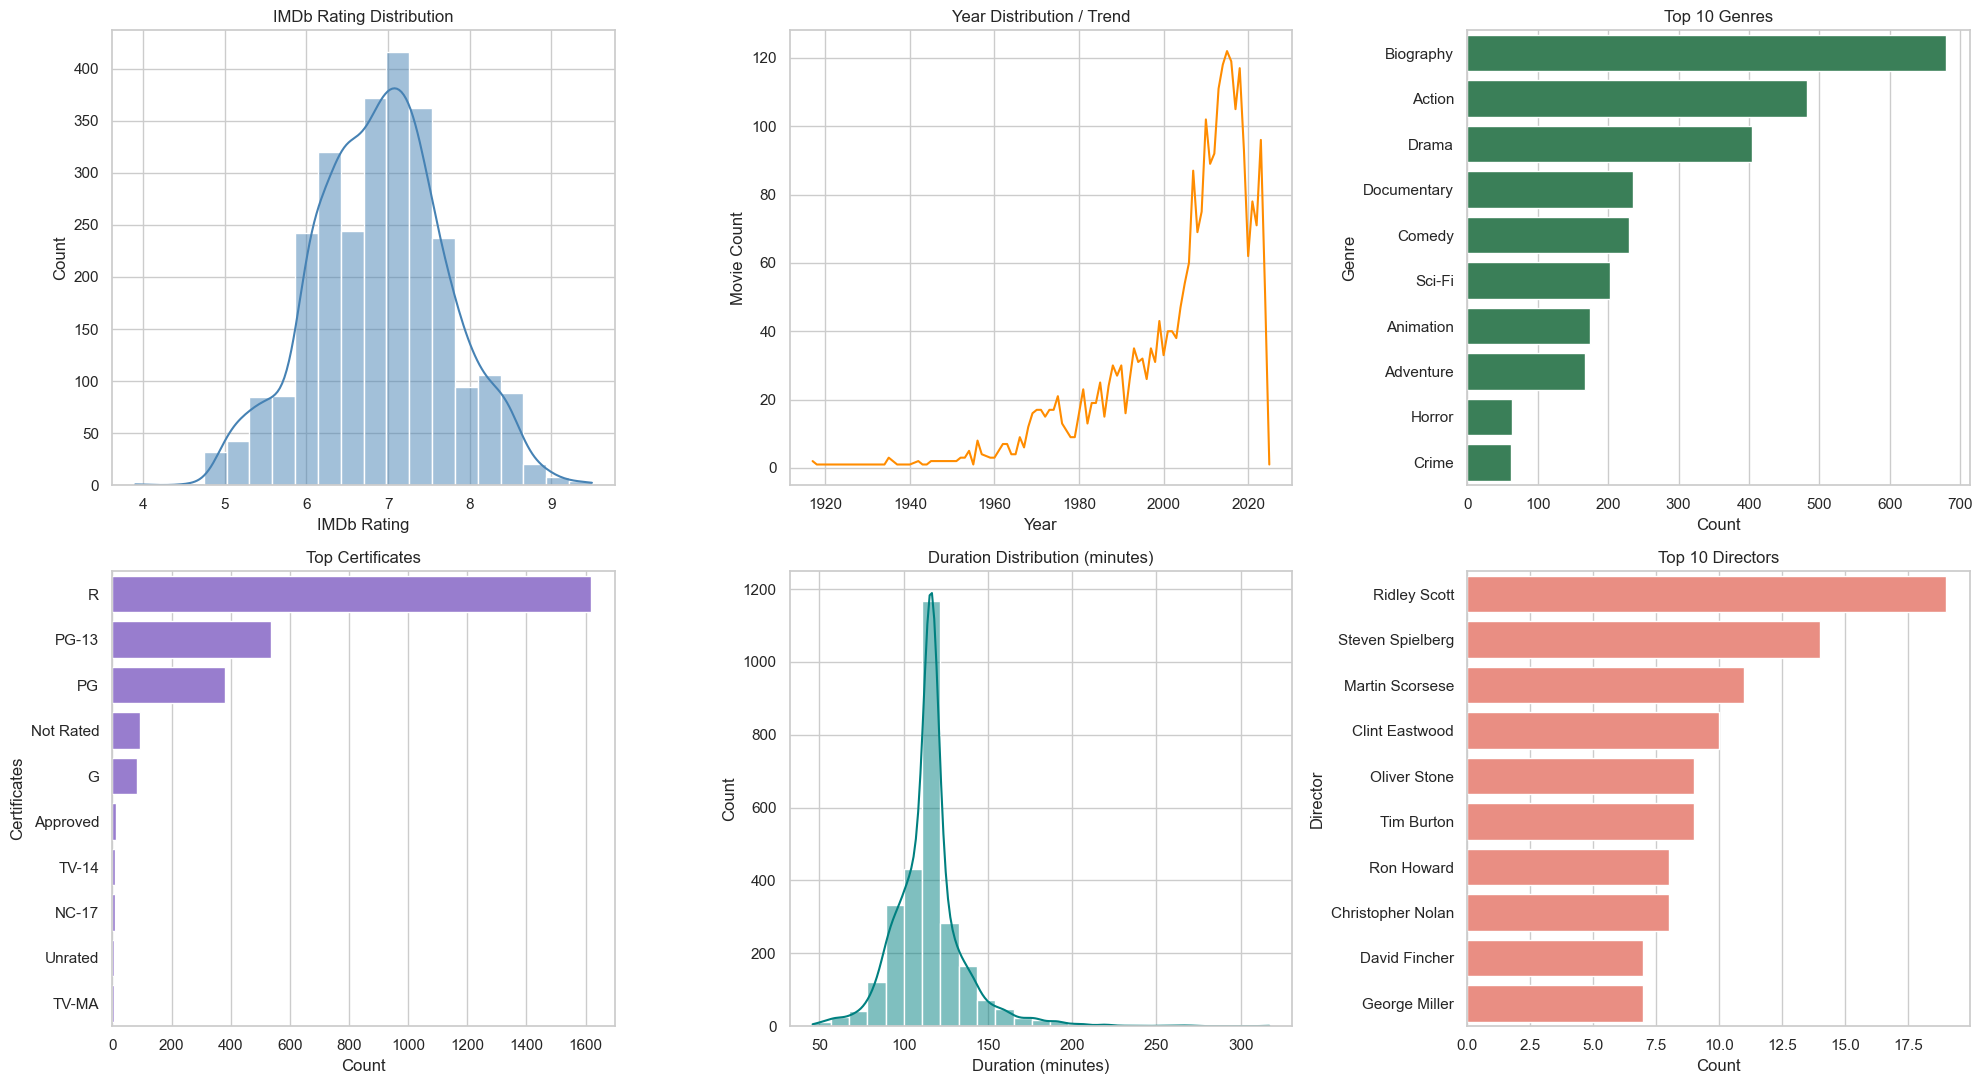

Cast quality audit


,metric,value
0,Rows with reliable cast delimiters,0
1,Rows excluded from actor retrieval,2762
2,Rows where heuristic split likely breaks names,6
3,Unique raw cast strings,2592


Examples where camel-case splitting likely breaks names


,Title,Year,Genre,Star Cast,heuristic_split_preview
786,Haunted Mansion,2023,Comedy,LaKeith StanfieldRosario DawsonOwen Wilson,"[La, Keith Stanfield, Rosario Dawson, Owen Wil..."
819,Chip 'n Dale: Rescue Rangers,2022,Animation,Andy SambergJohn MulaneyKiKi Layne,"[Andy Samberg, John Mulaney, Ki, Ki Layne]"
878,Imaginary,2024,Horror,DeWanda WiseTaegen BurnsPyper Braun,"[De, Wanda Wise, Taegen Burns, Pyper Braun]"
1064,The Fresh Air Will Do You Good,2008,Sci-Fi,Heather BrennerGiGi ErnetaNicholas Jaqua,"[Heather Brenner, Gi, Gi Erneta, Nicholas Jaqua]"
1682,TSC 3: Dawn of the Apocalypse,2011,Sci-Fi,LaDonna AllisonMadeline BrumbyDavid Lee Denny Jr.,"[La, Donna Allison, Madeline Brumby, David Lee..."
2233,Korengal,2014,Documentary,LaMonta CaldwellMiguel CortezStephen Gillespie,"[La, Monta Caldwell, Miguel Cortez, Stephen Gi..."


Top repeated raw cast strings (warning sign of cross-title contamination)


,row_count
Star Cast,
Daniel RadcliffeEmma WatsonRupert Grint,140
J.R.R. TolkienFran WalshPhilippa Boyens,3
Yoshiyuki Tomino,3
Lucas HeppeRyan E. HeppeAndrew Hicks,3
Hayao Miyazaki,3
Hyung-rae ShimEun-kyeong JeonKim Su-Mi,2
Alan Bennett,2
Chris McKennaErik SommersStan Lee,2
Jane GoldmanMatthew VaughnMark Millar,2


In [ ]:
# Why this cell: these views reveal coverage, skew, and bias risks that directly affect user experience.
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

sns.histplot(clean_df["IMDb Rating"], bins=20, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("IMDb Rating Distribution")

year_counts = clean_df["Year"].value_counts().sort_index()
axes[0, 1].plot(year_counts.index, year_counts.values, color="darkorange")
axes[0, 1].set_title("Year Distribution / Trend")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Movie Count")

top_genres = clean_df["Genre"].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0, 2], color="seagreen")
axes[0, 2].set_title("Top 10 Genres")
axes[0, 2].set_xlabel("Count")

top_certificates = clean_df["Certificates"].value_counts().head(10)
sns.barplot(x=top_certificates.values, y=top_certificates.index, ax=axes[1, 0], color="mediumpurple")
axes[1, 0].set_title("Top Certificates")
axes[1, 0].set_xlabel("Count")

sns.histplot(clean_df["Duration (minutes)"], bins=25, kde=True, ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Duration Distribution (minutes)")

top_directors = clean_df["Director"].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, ax=axes[1, 2], color="salmon")
axes[1, 2].set_title("Top 10 Directors")
axes[1, 2].set_xlabel("Count")

plt.tight_layout()
plt.show()

# Why this diagnostic: we want to show both the original failure mode and the parsed actor output used for retrieval.
def split_cast_heuristic(star_cast: str) -> list[str]:
    tokens = re.sub(r"(?<=[a-z])(?=[A-Z])", "|", str(star_cast)).split("|")
    return [t.strip() for t in tokens if t.strip()]

cast_quality_audit = pd.DataFrame(
    {
        "metric": [
            "Rows with parsed cast suitable for retrieval",
            "Rows with low-confidence cast parsing",
            "Unique parsed actor names",
            "Actor-movie rows after explode",
        ],
        "value": [
            int(clean_df["star_cast_reliable"].sum()),
            int((~clean_df["star_cast_reliable"]).sum()),
            int(clean_df["parsed_star_cast"].explode().dropna().nunique()),
            int(clean_df["parsed_star_cast"].explode().dropna().shape[0]),
        ],
    }
)

print("Cast quality audit")
display(cast_quality_audit)

cast_parse_examples = clean_df[["Title", "Year", "Star Cast", "parsed_star_cast"]].head(10).copy()
cast_parse_examples["naive_split_preview"] = cast_parse_examples["Star Cast"].apply(split_cast_heuristic)

print("Examples comparing the raw cast string, naive split, and parsed actor list")
display(cast_parse_examples)

top_actor_counts = (
    clean_df.loc[clean_df["star_cast_reliable"], "parsed_star_cast"]
    .explode()
    .value_counts()
    .head(15)
    .to_frame(name="parsed_movie_count")
)

print("Top parsed actor counts after cast cleaning")
display(top_actor_counts)

## Key Part 1 Insights (Business + Modeling)
- The dataset is structurally complete (no nulls), which lowers preprocessing risk and lets us focus on retrieval quality early.
- Exact row duplicates exist and should be removed; otherwise repeated rows can bias similarity search toward duplicate movies.
- Duplicate titles are common, so year-aware IDs are essential to avoid mixing remakes and originals in responses.
- Genre distribution is imbalanced (e.g., Biography/Action/Drama concentration), so recommendations may skew unless prompts or reranking compensate.
- Certificate distribution is heavily weighted toward `R` and `PG-13`, which can support age-rating filters in future conversational constraints.
- Ratings and duration distributions give useful defaults for user queries like "highly rated under 2 hours".
- The raw `Star Cast` field is concatenated and cannot be used directly for actor retrieval.
- A best-effort cast parser recovers actor names such as `Christoph Waltz`, `Vanessa Redgrave`, and `Annette Bening` into separate entries, which makes actor-based search possible.
- The parser is still heuristic rather than ground truth, so actor retrieval is improved but should still be described as best-effort in the case study write-up.


In [ ]:
# Why this cell: one canonical text field simplifies embedding/indexing and improves consistency across query types.
def build_search_text(row: pd.Series) -> str:
    cast_fragment = ""
    if row["parsed_star_cast"]:
        cast_fragment = "Star Cast: " + ", ".join(row["parsed_star_cast"]) + ". "
    return (
        f"Title: {row['Title']}. "
        f"Year: {int(row['Year'])}. "
        f"Genre: {row['Genre']}. "
        f"Director: {row['Director']}. "
        f"{cast_fragment}"
        f"IMDb Rating: {row['IMDb Rating']}. "
        f"MetaScore: {row['MetaScore']}. "
        f"Certificate: {row['Certificates']}. "
        f"Duration (minutes): {row['Duration (minutes)']}."
    )

clean_df["search_text"] = clean_df.apply(build_search_text, axis=1)
cast_member_df = (
    clean_df[["movie_id", "Title", "Year", "parsed_star_cast"]]
    .explode("parsed_star_cast")
    .rename(columns={"parsed_star_cast": "cast_member"})
    .dropna(subset=["cast_member"])
    .reset_index(drop=True)
)

display_columns = [
    "movie_id",
    "Title",
    "Year",
    "Genre",
    "IMDb Rating",
    "MetaScore",
    "Director",
    "Star Cast",
    "parsed_star_cast",
    "star_cast_reliable",
    "Poster-src",
    "Duration (minutes)",
    "Certificates",
    "search_text",
]

clean_df = clean_df[display_columns].copy()
print(f"clean_df shape: {clean_df.shape}")
print(f"Actor-level rows in cast_member_df: {len(cast_member_df)}")
print("Parsed cast names are now included in search_text so actor queries can participate in retrieval.")
clean_df.head(3)

In [ ]:
# Why this cell: we do lightweight, pre-embedding retrieval checks to verify that search_text supports common intents.
def keyword_filter_search(df: pd.DataFrame, keywords: list[str], top_n: int = 5) -> pd.DataFrame:
    mask = pd.Series(True, index=df.index)
    for kw in keywords:
        mask &= df["search_text"].str.contains(kw, case=False, regex=False)
    cols = ["movie_id", "Title", "Year", "Genre", "IMDb Rating"]
    return df.loc[mask, cols].sort_values(by="IMDb Rating", ascending=False).head(top_n)

test_queries = [
    {"query": "Find action movies rated above 8", "keywords": ["Action", "IMDb Rating: 8"]},
    {"query": "Show me biography films directed by Christopher Nolan", "keywords": ["Biography", "Christopher Nolan"]},
    {"query": "Any PG-13 adventure movies?", "keywords": ["PG-13", "Adventure"]},
    {"query": "Give me highly rated drama movies", "keywords": ["Drama", "IMDb Rating"]},
    {"query": "Movies around 90 minutes", "keywords": ["Duration (minutes): 9"]},
    {"query": "Give me Christoph Waltz movies", "keywords": ["Christoph Waltz"]},
]

for i, item in enumerate(test_queries, start=1):
    print(f"\nTest {i}: {item['query']}")
    print(f"Keywords used: {item['keywords']}")
    display(keyword_filter_search(clean_df, item['keywords']))

print("\nAmbiguous-title spot check (same title, different year):")
for title in ["Aladdin", "Dune", "Ghostbusters"]:
    subset = clean_df[clean_df["Title"].str.lower() == title.lower()][["movie_id", "Title", "Year", "IMDb Rating"]]
    if len(subset) > 0:
        display(subset.sort_values("Year"))

## Part 1 Complete: Data Contract for Part 2
- **Primary dataframe:** `clean_df`
- **Required retrieval columns:** `movie_id`, `search_text`
- **Actor retrieval support:** `parsed_star_cast` stores the best-effort parsed actor list, and `cast_member_df` stores the exploded actor-to-movie mapping used for actor queries.
- **Required response rendering columns:** `Title`, `Year`, `Genre`, `IMDb Rating`, `Director`, `MetaScore`, `Poster-src`, `Duration (minutes)`, `Certificates`
- **Audit fields:** `Star Cast` preserves the raw source string, and `star_cast_reliable` marks whether the parsed result was strong enough for actor-aware filtering.

Optional checkpoint export (uncomment if desired):
```python
# clean_df.to_csv("imdb_clean_for_retrieval.csv", index=False)
```


---
## Part 2+ Scaffold (from template)
Continue below for chunking, embeddings, vector store, LLM chain, and UI integration.


In [ ]:
# Why this cell: we prepare retrieval documents once so all downstream steps use a consistent data contract.
# Optional install (uncomment if needed in a fresh environment):
# !pip install -q langchain langchain-openai langchain-community faiss-cpu gradio tiktoken

import os
from typing import Dict, List, Tuple, Optional

from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter

assert "clean_df" in globals(), "Run Part 1 first so clean_df is available."

def row_to_document(row: pd.Series) -> Document:
    """Convert each movie row into a retrieval document with rich metadata for response formatting."""
    metadata = {
        "movie_id": row["movie_id"],
        "title": row["Title"],
        "year": int(row["Year"]),
        "genre": row["Genre"],
        "imdb_rating": float(row["IMDb Rating"]),
        "metascore": float(row["MetaScore"]),
        "director": row["Director"],
        "star_cast": row["Star Cast"],
        "parsed_star_cast": row["parsed_star_cast"],
        "star_cast_reliable": bool(row["star_cast_reliable"]),
        "certificate": row["Certificates"],
        "duration_minutes": float(row["Duration (minutes)"]),
        "poster_src": row["Poster-src"],
    }
    return Document(page_content=row["search_text"], metadata=metadata)

movie_docs = [row_to_document(r) for _, r in clean_df.iterrows()]

# We still chunk text even though rows are short, so this scales if richer descriptions are added later.
text_splitter = RecursiveCharacterTextSplitter(chunk_size=350, chunk_overlap=40)
chunked_docs = text_splitter.split_documents(movie_docs)

print(f"Movie documents: {len(movie_docs)}")
print(f"Chunked documents: {len(chunked_docs)}")

In [ ]:
# Why this cell: embeddings turn text into vectors so semantic queries can match relevant movies.
# VS Code/local-first key loading: read from .env, then environment variables, then Colab Secrets if available.
from pathlib import Path
from langchain_openai import OpenAIEmbeddings

try:
    from dotenv import load_dotenv
except ImportError as exc:
    raise ImportError(
        "python-dotenv is required for local .env loading in VS Code. Install it with `%pip install python-dotenv`."
    ) from exc

load_dotenv(dotenv_path=Path.cwd() / ".env", override=False)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    try:
        from google.colab import userdata  # type: ignore
        OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
    except Exception:
        OPENAI_API_KEY = None

if not OPENAI_API_KEY:
    raise ValueError(
        "Set OPENAI_API_KEY in a local .env file (recommended for VS Code), or provide it via an environment variable/Colab Secret before running Part 2."
    )

embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENAI_API_KEY,
)

print("Embedding model is ready.")

In [ ]:
# Why this cell: FAISS gives fast nearest-neighbor search over movie vectors for low-latency retrieval.
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(chunked_docs, embedding_model)

print("FAISS vector store created.")
print(f"Indexed vectors: {vector_store.index.ntotal}")


In [ ]:
# Why this cell: the chat model turns retrieved context into a conversational, user-friendly answer.
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2,
    api_key=OPENAI_API_KEY,
)

print("LLM is ready.")


In [ ]:
# Why this cell: a strong prompt controls answer quality, structure, and product feel for movie discovery.
from langchain.prompts import ChatPromptTemplate

qa_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an IMDb movie discovery concierge. Your job is to help users discover movies with taste, clarity, and strong reasoning. "
        "Use only retrieved context for factual details. Never invent titles, ratings, or credits. "
        "Sound like a sharp, enthusiastic movie expert: concise, engaging, and insightful rather than generic. "
        "When recommending, explain why the picks fit by referencing genre, tone, pacing, director, era, runtime, or ratings when available. "
        "Balance precision with delight: make the user feel guided, not overwhelmed. "
        "If the user gives weak or broad input, offer a short clarifying question that meaningfully narrows the next turn.",
    ),
    (
        "human",
        "Conversation history:\\n{chat_history}\\n\\n"
        "User question:\\n{question}\\n\\n"
        "Interpreted preference summary:\\n{preference_summary}\\n\\n"
        "Retrieved context:\\n{context}\\n\\n"
        "Return a concise markdown answer with this structure:\\n"
        "1) Quick Take\\n"
        "2) Why These Picks Fit\\n"
        "3) Recommended Movies\\n"
        "4) One Smart Follow-Up\\n"
        "If confidence is weak, say so clearly and avoid pretending certainty.",
    ),
])

print("Prompt template created.")

In [ ]:
# Why this cell: reusable helpers keep retrieval + generation logic clean, testable, and product-oriented.
def history_to_text(chat_history: List[Tuple[str, str]], max_turns: int = 6) -> str:
    """Compress recent turns so follow-up questions preserve context without long prompts."""
    if not chat_history:
        return "No prior conversation."
    recent_turns = chat_history[-max_turns:]
    lines = []
    for user_msg, bot_msg in recent_turns:
        lines.append(f"User: {user_msg}")
        lines.append(f"Assistant: {bot_msg}")
    return "\n".join(lines)

def docs_to_context(docs: List[Document], max_docs: int = 5) -> str:
    """Format retrieved docs into compact context blocks for the LLM."""
    selected = docs[:max_docs]
    blocks = []
    for i, d in enumerate(selected, start=1):
        m = d.metadata
        blocks.append(
            f"[{i}] {m.get('title')} ({m.get('year')}) | Genre: {m.get('genre')} | "
            f"IMDb: {m.get('imdb_rating')} | Director: {m.get('director')} | "
            f"Certificate: {m.get('certificate')} | Runtime: {m.get('duration_minutes')} min\n"
            f"{d.page_content}"
        )
    return "\n\n".join(blocks) if blocks else "No relevant context found."

def generate_answer(
    question: str,
    docs: List[Document],
    chat_history: List[Tuple[str, str]],
    preference_summary: str,
 ) -> str:
    """Run the prompt + model step to generate the final conversational answer."""
    prompt_value = qa_prompt.format_prompt(
        chat_history=history_to_text(chat_history),
        question=question,
        preference_summary=preference_summary,
        context=docs_to_context(docs),
    )
    response = llm.invoke(prompt_value.to_messages())
    return response.content

In [ ]:
# Why this cell: retrieval configuration, structured filters, and preference-aware reranking power the product's relevance and flexibility.
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 30},
)

def retrieve_docs(query: str, k: int = 5) -> List[Document]:
    return retriever.invoke(query)[:k]

def retrieve_docs_with_scores(query: str, k: int = 30):
    """Useful for diagnostics and preference-aware reranking. Lower FAISS distance = closer semantic match."""
    return vector_store.similarity_search_with_score(query, k=k)

KNOWN_CERTIFICATES = ["G", "PG", "PG-13", "R", "NC-17", "Not Rated", "Approved", "TV-14", "TV-PG", "TV-MA"]
KNOWN_GENRES = sorted(clean_df["Genre"].dropna().astype(str).unique().tolist(), key=len, reverse=True)

def _normalize_lookup_text(text: str) -> str:
    return re.sub(r"[^a-z0-9 ]+", " ", str(text).lower()).strip()

def _genre_tokens(value: str) -> set[str]:
    return {part.strip().lower() for part in str(value).split(",") if part.strip()}

MOVIE_RECORDS = clean_df[["Title", "Year", "Genre", "Director", "IMDb Rating", "Certificates", "parsed_star_cast"]].to_dict("records")
TITLE_LOOKUP_ROWS = {_normalize_lookup_text(row["Title"]): row for row in MOVIE_RECORDS}
DIRECTOR_LOOKUP_ROWS = {_normalize_lookup_text(row["Director"]): row for row in MOVIE_RECORDS}
ACTOR_LOOKUP_NAMES = sorted(cast_member_df["cast_member"].dropna().astype(str).unique().tolist(), key=len, reverse=True)
ACTOR_LOOKUP_ROWS = {_normalize_lookup_text(name): name for name in ACTOR_LOOKUP_NAMES}

def _duration_to_minutes(value: float, unit: str) -> float:
    unit = unit.lower()
    if unit.startswith("h"):
        return float(value) * 60.0
    return float(value)

def extract_query_constraints(query: str) -> Dict:
    """Parse lightweight SQL-like constraints from natural language."""
    q = str(query).lower()
    q_norm = _normalize_lookup_text(query)
    constraints = {
        "genre": None,
        "certificate": None,
        "actor_name": None,
        "imdb_min": None,
        "imdb_max": None,
        "year_min": None,
        "year_max": None,
        "duration_min": None,
        "duration_max": None,
        "prefer_high_rating": False,
    }

    if any(phrase in q for phrase in ["highly rated", "top rated", "best rated", "highest rated"]):
        constraints["prefer_high_rating"] = True

    for genre in KNOWN_GENRES:
        if re.search(rf"\b{re.escape(genre.lower())}\b", q):
            constraints["genre"] = genre
            break

    for cert in sorted(KNOWN_CERTIFICATES, key=len, reverse=True):
        if re.search(rf"\b{re.escape(cert.lower())}\b", q):
            constraints["certificate"] = cert
            break

    for actor_norm, actor_name in ACTOR_LOOKUP_ROWS.items():
        if actor_norm and re.search(rf"\b{re.escape(actor_norm)}\b", q_norm):
            constraints["actor_name"] = actor_name
            break

    rating_min_patterns = [
        r"(?:imdb\s*rating|rating|rated)\s*(?:above|over|greater than|at least|>=)\s*(\d+(?:\.\d+)?)",
        r"(?:above|over|greater than|at least|>=)\s*(\d+(?:\.\d+)?)\s*(?:imdb\s*rating|rating)",
        r"(?:minimum|min)\s*(?:imdb\s*rating|rating)\s*(\d+(?:\.\d+)?)",
        r"(?:rated)\s*(\d+(?:\.\d+)?)\s*(?:and above|or above|plus)",
        r"(\d+(?:\.\d+)?)\s*(?:and above|or above)\s*(?:on imdb|imdb|rating)?",
    ]
    rating_max_patterns = [
        r"(?:imdb\s*rating|rating|rated)\s*(?:below|under|less than|at most|<=)\s*(\d+(?:\.\d+)?)",
        r"(?:below|under|less than|at most|<=)\s*(\d+(?:\.\d+)?)\s*(?:imdb\s*rating|rating)",
        r"(?:maximum|max)\s*(?:imdb\s*rating|rating)\s*(\d+(?:\.\d+)?)",
    ]

    for pattern in rating_min_patterns:
        m = re.search(pattern, q)
        if m:
            constraints["imdb_min"] = float(m.group(1))
            constraints["prefer_high_rating"] = True
            break

    for pattern in rating_max_patterns:
        m = re.search(pattern, q)
        if m:
            constraints["imdb_max"] = float(m.group(1))
            break

    m = re.search(r"(?:after|newer than)\s*(19\d{2}|20\d{2})", q)
    if m:
        constraints["year_min"] = int(m.group(1)) + 1

    m = re.search(r"(?:since|from|after or in)\s*(19\d{2}|20\d{2})", q)
    if m and constraints["year_min"] is None:
        constraints["year_min"] = int(m.group(1))

    m = re.search(r"(?:before|older than)\s*(19\d{2}|20\d{2})", q)
    if m:
        constraints["year_max"] = int(m.group(1)) - 1

    m = re.search(r"(?:in|from)\s*(19\d{2}|20\d{2})", q)
    if m and constraints["year_min"] is None and constraints["year_max"] is None:
        year_exact = int(m.group(1))
        constraints["year_min"] = year_exact
        constraints["year_max"] = year_exact

    duration_min_match = re.search(r"(?:over|above|more than|at least|>=)\s*(\d+(?:\.\d+)?)\s*(hours?|hrs?|hr|minutes?|mins?|min)", q)
    if duration_min_match:
        value = float(duration_min_match.group(1))
        unit = duration_min_match.group(2)
        constraints["duration_min"] = _duration_to_minutes(value, unit)

    duration_max_match = re.search(r"(?:under|below|less than|at most|<=)\s*(\d+(?:\.\d+)?)\s*(hours?|hrs?|hr|minutes?|mins?|min)", q)
    if duration_max_match:
        value = float(duration_max_match.group(1))
        unit = duration_max_match.group(2)
        constraints["duration_max"] = _duration_to_minutes(value, unit)

    return constraints

def extract_preference_profile(query: str, chat_history: Optional[List[Tuple[str, str]]] = None) -> Dict:
    """Infer soft preference signals from the current turn and recent chat history."""
    if chat_history is None:
        chat_history = []

    history_text = " ".join(user_msg for user_msg, _ in chat_history[-4:])
    combined_text = f"{query} {history_text}"
    combined_norm = _normalize_lookup_text(combined_text)

    mentioned_titles = []
    for title_norm, row in TITLE_LOOKUP_ROWS.items():
        if title_norm and re.search(rf"\b{re.escape(title_norm)}\b", combined_norm):
            mentioned_titles.append(row["Title"])

    mentioned_directors = []
    for director_norm, row in DIRECTOR_LOOKUP_ROWS.items():
        if director_norm and re.search(rf"\b{re.escape(director_norm)}\b", combined_norm):
            mentioned_directors.append(row["Director"])

    mentioned_actors = []
    for actor_norm, actor_name in ACTOR_LOOKUP_ROWS.items():
        if actor_norm and re.search(rf"\b{re.escape(actor_norm)}\b", combined_norm):
            mentioned_actors.append(actor_name)

    preferred_genres = set()
    for genre in KNOWN_GENRES:
        if re.search(rf"\b{re.escape(genre.lower())}\b", combined_text.lower()):
            preferred_genres.update(_genre_tokens(genre))

    era_preferences = []
    for title in mentioned_titles:
        row = TITLE_LOOKUP_ROWS.get(_normalize_lookup_text(title))
        if row:
            preferred_genres.update(_genre_tokens(row["Genre"]))
            era_preferences.append(int(row["Year"]))

    for director in mentioned_directors:
        row = DIRECTOR_LOOKUP_ROWS.get(_normalize_lookup_text(director))
        if row:
            preferred_genres.update(_genre_tokens(row["Genre"]))

    mood_map = {
        "dark": {"thriller", "crime", "mystery"},
        "light": {"comedy", "animation", "family"},
        "emotional": {"drama", "romance"},
        "mind bending": {"sci-fi", "mystery", "thriller"},
        "feel good": {"comedy", "family", "musical"},
        "intense": {"action", "thriller", "war"},
    }

    matched_moods = []
    lowered = combined_text.lower()
    for phrase, genres in mood_map.items():
        if phrase in lowered:
            matched_moods.append(phrase)
            preferred_genres.update(genres)

    return {
        "mentioned_titles": sorted(set(mentioned_titles)),
        "mentioned_directors": sorted(set(mentioned_directors)),
        "mentioned_actors": sorted(set(mentioned_actors)),
        "preferred_genres": sorted(preferred_genres),
        "preferred_era": round(sum(era_preferences) / len(era_preferences)) if era_preferences else None,
        "matched_moods": matched_moods,
    }

def _has_hard_constraints(constraints: Dict) -> bool:
    hard_keys = ["genre", "certificate", "actor_name", "imdb_min", "imdb_max", "year_min", "year_max", "duration_min", "duration_max"]
    return any(constraints.get(k) is not None for k in hard_keys)

def _doc_satisfies_hard_constraints(doc: Document, constraints: Dict) -> bool:
    m = doc.metadata

    if constraints.get("genre") and constraints["genre"].lower() not in str(m.get("genre", "")).lower():
        return False

    if constraints.get("certificate") and str(m.get("certificate", "")).lower() != constraints["certificate"].lower():
        return False

    if constraints.get("actor_name") and constraints["actor_name"] not in list(m.get("parsed_star_cast", [])):
        return False

    imdb = float(m.get("imdb_rating", 0.0))
    year = int(m.get("year", 0))
    duration = float(m.get("duration_minutes", 0.0))

    if constraints.get("imdb_min") is not None and imdb < constraints["imdb_min"]:
        return False
    if constraints.get("imdb_max") is not None and imdb > constraints["imdb_max"]:
        return False
    if constraints.get("year_min") is not None and year < constraints["year_min"]:
        return False
    if constraints.get("year_max") is not None and year > constraints["year_max"]:
        return False
    if constraints.get("duration_min") is not None and duration < constraints["duration_min"]:
        return False
    if constraints.get("duration_max") is not None and duration > constraints["duration_max"]:
        return False

    return True

def _semantic_similarity(distance: float) -> float:
    return 1.0 / (1.0 + max(float(distance), 0.0))

def summarize_constraints(constraints: Dict) -> str:
    parts = []
    if constraints.get("genre"):
        parts.append(f"genre={constraints['genre']}")
    if constraints.get("certificate"):
        parts.append(f"certificate={constraints['certificate']}")
    if constraints.get("actor_name"):
        parts.append(f"actor={constraints['actor_name']}")
    if constraints.get("imdb_min") is not None:
        parts.append(f"imdb>={constraints['imdb_min']}")
    if constraints.get("imdb_max") is not None:
        parts.append(f"imdb<={constraints['imdb_max']}")
    if constraints.get("year_min") is not None:
        parts.append(f"year>={constraints['year_min']}")
    if constraints.get("year_max") is not None:
        parts.append(f"year<={constraints['year_max']}")
    if constraints.get("duration_min") is not None:
        parts.append(f"duration>={int(constraints['duration_min'])}m")
    if constraints.get("duration_max") is not None:
        parts.append(f"duration<={int(constraints['duration_max'])}m")
    return ", ".join(parts) if parts else "none"

def summarize_preferences(preference_profile: Dict) -> str:
    parts = []
    if preference_profile.get("mentioned_titles"):
        parts.append("reference titles=" + ", ".join(preference_profile["mentioned_titles"][:3]))
    if preference_profile.get("mentioned_directors"):
        parts.append("reference directors=" + ", ".join(preference_profile["mentioned_directors"][:2]))
    if preference_profile.get("mentioned_actors"):
        parts.append("reference actors=" + ", ".join(preference_profile["mentioned_actors"][:2]))
    if preference_profile.get("preferred_genres"):
        parts.append("soft genres=" + ", ".join(preference_profile["preferred_genres"][:4]))
    if preference_profile.get("preferred_era") is not None:
        parts.append(f"preferred era around {preference_profile['preferred_era']}")
    if preference_profile.get("matched_moods"):
        parts.append("mood cues=" + ", ".join(preference_profile["matched_moods"][:2]))
    return "; ".join(parts) if parts else "no strong soft preferences detected"

def _build_reason_tags(doc: Document, constraints: Dict, preference_profile: Dict) -> List[str]:
    tags = []
    metadata = doc.metadata
    doc_genres = _genre_tokens(metadata.get("genre", ""))
    doc_cast = set(metadata.get("parsed_star_cast", []))

    if constraints.get("genre") and constraints["genre"].lower() in str(metadata.get("genre", "")).lower():
        tags.append(f"matches requested genre ({constraints['genre']})")
    if constraints.get("certificate") and str(metadata.get("certificate", "")).lower() == constraints["certificate"].lower():
        tags.append(f"fits certificate ({constraints['certificate']})")
    if constraints.get("actor_name") and constraints["actor_name"] in doc_cast:
        tags.append(f"includes {constraints['actor_name']}")
    if constraints.get("duration_max") is not None and float(metadata.get("duration_minutes", 0.0)) <= constraints["duration_max"]:
        tags.append("fits runtime target")
    if constraints.get("year_min") is not None or constraints.get("year_max") is not None:
        tags.append("fits release window")
    if constraints.get("imdb_min") is not None and float(metadata.get("imdb_rating", 0.0)) >= constraints["imdb_min"]:
        tags.append("meets rating threshold")

    preferred_genres = set(preference_profile.get("preferred_genres", []))
    genre_overlap = preferred_genres.intersection(doc_genres)
    if genre_overlap:
        tags.append("shares genre cues: " + ", ".join(sorted(genre_overlap)[:2]))

    preferred_actors = set(preference_profile.get("mentioned_actors", []))
    actor_overlap = preferred_actors.intersection(doc_cast)
    if actor_overlap and not constraints.get("actor_name"):
        tags.append("shares actor cues: " + ", ".join(sorted(actor_overlap)[:1]))

    if metadata.get("director") in preference_profile.get("mentioned_directors", []):
        tags.append("same director as your reference")

    if float(metadata.get("imdb_rating", 0.0)) >= 8.0:
        tags.append("strong IMDb signal")

    return tags[:3]

def filter_catalog_matches(df: pd.DataFrame, constraints: Dict) -> pd.DataFrame:
    """Apply explicit hard constraints directly on the dataframe for exhaustive list-style requests."""
    filtered_df = df.copy()

    if constraints.get("genre"):
        filtered_df = filtered_df[
            filtered_df["Genre"].astype(str).str.contains(re.escape(constraints["genre"]), case=False, regex=True, na=False)
        ]
    if constraints.get("certificate"):
        filtered_df = filtered_df[
            filtered_df["Certificates"].astype(str).str.lower() == constraints["certificate"].lower()
        ]
    if constraints.get("actor_name"):
        filtered_df = filtered_df[
            filtered_df["parsed_star_cast"].apply(lambda names: constraints["actor_name"] in names if isinstance(names, list) else False)
        ]
    if constraints.get("imdb_min") is not None:
        filtered_df = filtered_df[filtered_df["IMDb Rating"] >= constraints["imdb_min"]]
    if constraints.get("imdb_max") is not None:
        filtered_df = filtered_df[filtered_df["IMDb Rating"] <= constraints["imdb_max"]]
    if constraints.get("year_min") is not None:
        filtered_df = filtered_df[filtered_df["Year"] >= constraints["year_min"]]
    if constraints.get("year_max") is not None:
        filtered_df = filtered_df[filtered_df["Year"] <= constraints["year_max"]]
    if constraints.get("duration_min") is not None:
        filtered_df = filtered_df[filtered_df["Duration (minutes)"] >= constraints["duration_min"]]
    if constraints.get("duration_max") is not None:
        filtered_df = filtered_df[filtered_df["Duration (minutes)"] <= constraints["duration_max"]]

    filtered_df = filtered_df.sort_values(["IMDb Rating", "Year", "Title"], ascending=[False, False, True]).reset_index(drop=True)
    return filtered_df

def rerank_with_constraints(candidates_with_scores, constraints: Dict, preference_profile: Dict, top_k: int = 5) -> Dict:
    """Hybrid ranking: semantic similarity + hard filters + soft preference personalization."""
    best_by_movie_id = {}
    for doc, distance in candidates_with_scores:
        movie_id = doc.metadata.get("movie_id")
        if movie_id not in best_by_movie_id or distance < best_by_movie_id[movie_id][1]:
            best_by_movie_id[movie_id] = (doc, float(distance))

    unique_candidates = list(best_by_movie_id.values())

    scored_all = []
    ranking_details = {}
    preferred_genres = set(preference_profile.get("preferred_genres", []))
    preferred_directors = set(preference_profile.get("mentioned_directors", []))
    preferred_actors = set(preference_profile.get("mentioned_actors", []))
    preferred_era = preference_profile.get("preferred_era")

    for doc, distance in unique_candidates:
        metadata = doc.metadata
        semantic_score = _semantic_similarity(distance)
        rating = float(metadata.get("imdb_rating", 0.0))
        doc_genres = _genre_tokens(metadata.get("genre", ""))
        doc_cast = set(metadata.get("parsed_star_cast", []))

        rating_bonus = (rating / 10.0) * 0.10 if constraints.get("prefer_high_rating") else 0.0
        genre_bonus = 0.08 if preferred_genres.intersection(doc_genres) else 0.0
        director_bonus = 0.10 if metadata.get("director") in preferred_directors else 0.0
        actor_bonus = 0.12 if constraints.get("actor_name") and constraints["actor_name"] in doc_cast else 0.0
        actor_preference_bonus = 0.06 if preferred_actors.intersection(doc_cast) else 0.0
        era_bonus = 0.0
        if preferred_era is not None:
            era_bonus = max(0.0, 0.06 - (abs(int(metadata.get("year", 0)) - preferred_era) / 200.0))

        final_score = (0.72 * semantic_score) + rating_bonus + genre_bonus + director_bonus + actor_bonus + actor_preference_bonus + era_bonus
        scored_all.append((final_score, doc, distance))
        ranking_details[metadata.get("movie_id")] = {
            "final_score": round(final_score, 4),
            "semantic_score": round(semantic_score, 4),
            "reason_tags": _build_reason_tags(doc, constraints, preference_profile),
        }

    hard_match_scored = [x for x in scored_all if _doc_satisfies_hard_constraints(x[1], constraints)]

    used_constraint_fallback = False
    selected_pool = hard_match_scored

    if _has_hard_constraints(constraints) and len(hard_match_scored) == 0:
        selected_pool = scored_all
        used_constraint_fallback = True

    selected_pool = sorted(selected_pool, key=lambda x: x[0], reverse=True)[:top_k]
    reranked_docs = [doc for _, doc, _ in selected_pool]

    return {
        "docs": reranked_docs,
        "used_constraint_fallback": used_constraint_fallback,
        "constraint_summary": summarize_constraints(constraints),
        "preference_summary": summarize_preferences(preference_profile),
        "ranking_details": ranking_details,
        "constraints": constraints,
        "preference_profile": preference_profile,
    }

print("Retriever, actor-aware catalog filters, and preference-aware reranker are ready.")

In [ ]:
# Why this cell: this is the product orchestration core that turns retrieval into either conversational recommendations or structured catalog answers.
CATALOG_RESULT_LIMIT = 20

def rewrite_query_for_retrieval(query: str, assistant_mode: str, preference_profile: Dict) -> str:
    hints = []
    if assistant_mode == "recommendation":
        hints.append("prioritize recommendation-worthy titles with strong fit and broad appeal")
    if preference_profile.get("preferred_genres"):
        hints.append("preferred genres: " + ", ".join(preference_profile["preferred_genres"][:4]))
    if preference_profile.get("mentioned_directors"):
        hints.append("reference directors: " + ", ".join(preference_profile["mentioned_directors"][:2]))
    if preference_profile.get("mentioned_titles"):
        hints.append("reference titles: " + ", ".join(preference_profile["mentioned_titles"][:2]))
    if not hints:
        return query
    return query + " | " + " | ".join(hints)

def build_catalog_response(constraints: Dict, display_limit: int = CATALOG_RESULT_LIMIT) -> Dict:
    """Return exhaustive, filter-first answers for list-style catalog requests."""
    if not _has_hard_constraints(constraints):
        return {
            "status": "needs_clarification",
            "answer": "I can list matching titles, but I need at least one concrete filter such as genre, rating, year, certificate, or runtime.",
            "docs": [],
        }

    matched_df = filter_catalog_matches(clean_df, constraints)
    if matched_df.empty:
        return {
            "status": "no_match",
            "answer": f"I could not find any titles matching {summarize_constraints(constraints)} in this dataset.",
            "docs": [],
        }

    displayed_df = matched_df.head(display_limit).copy()
    displayed_docs = [row_to_document(row) for _, row in displayed_df.iterrows()]
    ranking_details = {
        doc.metadata.get("movie_id"): {
            "final_score": None,
            "semantic_score": None,
            "reason_tags": _build_reason_tags(doc, constraints, preference_profile={}),
        }
        for doc in displayed_docs
    }

    result_count = len(matched_df)
    displayed_count = len(displayed_df)
    if result_count > displayed_count:
        answer = (
            f"I found {result_count} matching titles for {summarize_constraints(constraints)}. "
            f"I am showing the top {displayed_count}, sorted by IMDb rating and recency."
        )
    else:
        answer = f"I found {result_count} matching titles for {summarize_constraints(constraints)}."

    return {
        "status": "ok",
        "answer": answer,
        "docs": displayed_docs,
        "result_rows": displayed_df.to_dict("records"),
        "result_count": result_count,
        "displayed_count": displayed_count,
        "constraints": constraints,
        "constraint_summary": summarize_constraints(constraints),
        "preference_profile": {},
        "preference_summary": "catalog list mode uses explicit filters rather than soft taste signals",
        "ranking_details": ranking_details,
        "used_constraint_fallback": False,
        "assistant_mode": "catalog",
    }

def run_chatbot_query(
    query: str,
    chat_history: Optional[List[Tuple[str, str]]] = None,
    assistant_mode: str = "search",
    top_k: int = 5,
    candidate_k: int = 30,
) -> Dict:
    if chat_history is None:
        chat_history = []

    constraints = extract_query_constraints(query)
    preference_profile = extract_preference_profile(query, chat_history=chat_history)

    if assistant_mode == "catalog":
        return build_catalog_response(constraints=constraints, display_limit=CATALOG_RESULT_LIMIT)

    retrieval_query = rewrite_query_for_retrieval(query, assistant_mode, preference_profile)
    candidates_with_scores = retrieve_docs_with_scores(retrieval_query, k=candidate_k)
    reranked = rerank_with_constraints(
        candidates_with_scores,
        constraints=constraints,
        preference_profile=preference_profile,
        top_k=top_k,
    )

    docs = reranked["docs"]
    answer = generate_answer(
        question=query,
        docs=docs,
        chat_history=chat_history,
        preference_summary=reranked["preference_summary"],
    )

    return {
        "status": "ok",
        "answer": answer,
        "docs": docs,
        "constraints": reranked["constraints"],
        "constraint_summary": reranked["constraint_summary"],
        "preference_profile": reranked["preference_profile"],
        "preference_summary": reranked["preference_summary"],
        "ranking_details": reranked["ranking_details"],
        "used_constraint_fallback": reranked["used_constraint_fallback"],
        "assistant_mode": assistant_mode,
    }

print("Core chatbot query runner is ready.")

In [ ]:
# Why this cell: presentation matters; strong formatting makes both recommendations and catalog answers easy to scan and trust.
def format_movie_matches(docs: List[Document], ranking_details: Optional[Dict] = None, max_items: int = 5) -> str:
    seen = set()
    lines = []

    for d in docs:
        m = d.metadata
        movie_id = m.get("movie_id")
        if movie_id in seen:
            continue
        seen.add(movie_id)

        detail = (ranking_details or {}).get(movie_id, {})
        reason_tags = detail.get("reason_tags", [])
        why_fit = "; ".join(reason_tags) if reason_tags else "strong semantic match"

        lines.append(
            f"- **{m.get('title')} ({m.get('year')})** | Genre: {m.get('genre')} | "
            f"IMDb: {m.get('imdb_rating')} | MetaScore: {m.get('metascore')} | "
            f"Director: {m.get('director')} | Runtime: {m.get('duration_minutes')} min\\n"
            f"  Why it fits: {why_fit}"
        )

        if len(lines) >= max_items:
            break

    return "\n".join(lines) if lines else "- No confident matches found."

def format_catalog_matches(result_rows: List[Dict]) -> str:
    lines = []
    for row in result_rows:
        lines.append(
            f"- **{row.get('Title')} ({int(row.get('Year'))})** | Genre: {row.get('Genre')} | "
            f"IMDb: {row.get('IMDb Rating')} | Director: {row.get('Director')} | "
            f"Runtime: {row.get('Duration (minutes)')} min"
        )
    return "\n".join(lines) if lines else "- No catalog matches found."

def format_final_response(payload: Dict) -> str:
    status = payload.get("status")
    if status != "ok":
        return payload.get("answer", "Something went wrong.")

    assistant_mode = payload.get("assistant_mode", "search")
    constraint_line = f"**Constraint read:** {payload.get('constraint_summary', 'none')}"

    if assistant_mode == "catalog":
        result_count = payload.get("result_count", 0)
        displayed_count = payload.get("displayed_count", 0)
        count_line = f"**Catalog match count:** {result_count}"
        shown_line = f"**Showing:** {displayed_count} title(s)"
        catalog_section = format_catalog_matches(payload.get("result_rows", []))
        return (
            f"{payload['answer']}\n\n"
            f"{count_line}\n{shown_line}\n{constraint_line}\n\n"
            f"### Matching Movies\n{catalog_section}"
        )

    movie_section = format_movie_matches(
        payload.get("docs", []),
        ranking_details=payload.get("ranking_details", {}),
        max_items=5,
    )

    preference_line = f"**Preference read:** {payload.get('preference_summary', 'none')}"

    compliance_line = ""
    compliance_report = payload.get("constraint_compliance_report")
    if compliance_report and compliance_report.get("has_hard_constraints"):
        rate = compliance_report.get("compliance_rate", 0.0)
        compliance_line = f"\n**Constraint compliance:** {rate:.0%}"

    fallback_line = ""
    if payload.get("used_constraint_fallback"):
        fallback_line = "\n**Fallback note:** No exact hard-constraint matches were found, so the assistant returned the closest high-similarity titles instead."

    return (
        f"{payload['answer']}\n\n"
        f"{preference_line}\n{constraint_line}{compliance_line}{fallback_line}\n\n"
        f"### Top Matched Movies\n{movie_section}"
    )

In [ ]:
# Why this cell: a curated demo flow showcases recommendation, personalization, and structured catalog search in interviews.
DEMO_REQUESTS = [
    {"query": "Recommend 3 highly rated action movies under 2 hours.", "mode": "recommendation"},
    {"query": "I loved Dune and Arrival. Give me something smart, immersive, and recent.", "mode": "recommendation"},
    {"query": "Give me all documentaries rated 8.0 and above.", "mode": "catalog"},
]

for i, demo_request in enumerate(DEMO_REQUESTS, start=1):
    print(f"\n{'=' * 24} Demo {i} {'=' * 24}")
    print(f"Query: {demo_request['query']}")
    demo_payload = run_chatbot_query(
        demo_request["query"],
        chat_history=[],
        assistant_mode=demo_request["mode"],
    )
    print(format_final_response(demo_payload))

## Debug Panel: Raw Semantic Retrieval vs Constraint-Aware Reranking

This section helps you **prove quality improvements** in your case study write-up.

- **Raw semantic retrieval** shows FAISS matches before constraints are applied.
- **Reranked output** shows final recommendations after applying query constraints (rating/year/duration/certificate/genre).

Use this when you want to explain *why* a result changed, not just *that* it changed.


## Interview Demo Flow

Use the demo cell above to present the project as a product, not just a notebook. A strong walkthrough shows three things in sequence:

1. **Discovery:** the assistant can handle broad natural-language search without forcing users into exact filters.
2. **Personalization:** the assistant uses reference titles, genre cues, and conversational context to refine recommendations.
3. **Trust and UX:** the assistant explains why the picks fit, states interpreted constraints, and degrades gracefully when confidence is weak.

This framing is useful in interviews because it highlights how GenAI can improve discovery, engagement, and recommendation trust in products such as Netflix, Spotify, YouTube, or any large catalog experience.

In [ ]:
# Why this cell: side-by-side diagnostics make retrieval behavior observable and explainable for grading.
def _candidate_rows_from_scores(candidates_with_scores):
    """Convert (Document, distance) pairs into a table for easy debugging and reporting."""
    rows = []
    for rank, (doc, distance) in enumerate(candidates_with_scores, start=1):
        m = doc.metadata
        rows.append({
            "raw_rank": rank,
            "movie_id": m.get("movie_id"),
            "title": m.get("title"),
            "year": m.get("year"),
            "genre": m.get("genre"),
            "certificate": m.get("certificate"),
            "imdb_rating": m.get("imdb_rating"),
            "duration_minutes": m.get("duration_minutes"),
            "faiss_distance": round(float(distance), 4),
        })
    return pd.DataFrame(rows)

def _doc_rows(docs: List[Document], ranking_details: Optional[Dict] = None, start_rank: int = 1):
    """Convert final reranked documents into a comparable table format."""
    rows = []
    for idx, doc in enumerate(docs, start=start_rank):
        m = doc.metadata
        movie_id = m.get("movie_id")
        detail = (ranking_details or {}).get(movie_id, {})
        rows.append({
            "final_rank": idx,
            "movie_id": movie_id,
            "title": m.get("title"),
            "year": m.get("year"),
            "genre": m.get("genre"),
            "certificate": m.get("certificate"),
            "imdb_rating": m.get("imdb_rating"),
            "duration_minutes": m.get("duration_minutes"),
            "reason_tags": ", ".join(detail.get("reason_tags", [])),
            "final_score": detail.get("final_score"),
        })
    return pd.DataFrame(rows)

def compare_raw_vs_reranked(query: str, raw_k: int = 12, final_k: int = 5):
    """
    Show before/after retrieval behavior for one query.

    What this returns:
    1) Parsed constraints for the query
    2) Soft preference profile inferred from the request/history
    3) Raw FAISS candidates (semantic only)
    4) Final reranked candidates (semantic + constraints + personalization)
    5) A delta view: which raw items were dropped from final output
    """
    constraints = extract_query_constraints(query)
    preference_profile = extract_preference_profile(query)
    raw_candidates = retrieve_docs_with_scores(query, k=raw_k)
    reranked = rerank_with_constraints(
        raw_candidates,
        constraints=constraints,
        preference_profile=preference_profile,
        top_k=final_k,
    )

    raw_df = _candidate_rows_from_scores(raw_candidates)
    final_df = _doc_rows(reranked["docs"], ranking_details=reranked["ranking_details"])

    final_ids = set(final_df["movie_id"].tolist()) if not final_df.empty else set()
    dropped_df = raw_df[~raw_df["movie_id"].isin(final_ids)].copy()

    print(f"Query: {query}")
    print(f"Parsed constraints: {summarize_constraints(constraints)}")
    print(f"Preference summary: {reranked['preference_summary']}")
    print(f"Used fallback: {reranked['used_constraint_fallback']}")

    print("\nRaw semantic candidates (before constraints/personalization):")
    display(raw_df.head(raw_k))

    print("Final reranked candidates (after personalization + constraints):")
    display(final_df)

    print("Dropped after reranking (useful for explanation):")
    display(dropped_df.head(raw_k))

    return {
        "constraints": constraints,
        "preference_profile": preference_profile,
        "used_constraint_fallback": reranked["used_constraint_fallback"],
        "raw_df": raw_df,
        "final_df": final_df,
        "dropped_df": dropped_df,
    }

# Example debug run (edit query as needed):
debug_report = compare_raw_vs_reranked(
    query="Recommend PG-13 adventure movies with IMDb rating above 7.5 after 2015 under 2 hours",
    raw_k=12,
    final_k=5,
)

## Multi-Agent Architecture

This project uses a lightweight **intent-routed multi-agent architecture** to improve user experience rather than forcing every request through one generic response path.

The orchestration design includes:

1. **Search Agent:** handles general movie discovery queries.
2. **Recommendation Agent:** handles taste-based suggestions and conversational recommendation requests.
3. **Catalog Agent:** handles exhaustive list-style requests such as "give me all documentaries rated 8.0 and above."
4. **Clarification Agent:** handles vague or underspecified requests by asking for one more useful signal.
5. **Orchestrator:** detects user intent and routes the query to the best agent for that task.

This notebook implements that orchestration with **LangChain components plus custom Python routing** so the submission stays simple and easy to follow in notebook form.

For interview and job-readiness, a separate **LangGraph-based implementation** is also included in `imdb_langgraph_app.py`, where the same agent pattern is modeled explicitly as a graph with routed state transitions.

This design is product-oriented because different user goals require different behaviors: discovery, recommendation, catalog lookup, and clarification should not all be treated the same way.

In [ ]:
# Why this cell: lightweight agents separate discovery, recommendation, catalog listing, and clarification behaviors.
def movie_search_agent(query: str, chat_history: List[Tuple[str, str]]) -> Dict:
    return run_chatbot_query(query, chat_history=chat_history, assistant_mode="search")

def recommendation_agent(query: str, chat_history: List[Tuple[str, str]]) -> Dict:
    return run_chatbot_query(query, chat_history=chat_history, assistant_mode="recommendation")

def catalog_agent(query: str, chat_history: List[Tuple[str, str]]) -> Dict:
    return run_chatbot_query(query, chat_history=chat_history, assistant_mode="catalog")

def clarification_agent() -> Dict:
    return {
        "status": "needs_clarification",
        "answer": "Give me one signal to work with such as genre, a movie you liked, an actor, mood, rating floor, or runtime.",
        "docs": [],
    }

In [ ]:
# Why this cell: orchestrator routes queries to the right experience based on user intent.
def detect_intent(query: str) -> str:
    q = query.lower()

    catalog_phrases = [
        "give me all",
        "show me all",
        "list all",
        "show all",
        "every documentary",
        "every movie",
        "every film",
    ]
    if any(phrase in q for phrase in catalog_phrases):
        return "catalog"
    if re.search(r"\b(all|every)\b", q) and _has_hard_constraints(extract_query_constraints(query)):
        return "catalog"

    if any(x in q for x in ["recommend", "suggest", "similar to", "what should i watch", "something like", "in the mood"]):
        return "recommendation"
    return "search"

def orchestrate_agents(query: str, chat_history: Optional[List[Tuple[str, str]]] = None) -> Dict:
    if chat_history is None:
        chat_history = []

    intent = detect_intent(query)
    if len(query.strip()) < 3:
        return clarification_agent()

    if intent == "catalog":
        return catalog_agent(query, chat_history)
    if intent == "recommendation":
        return recommendation_agent(query, chat_history)
    return movie_search_agent(query, chat_history)

In [ ]:
# Why this cell: robust guardrails protect UX while preserving a helpful, product-quality tone.
from time import perf_counter

MOVIE_HINT_TERMS = {
    "movie", "movies", "film", "films", "watch", "recommend", "recommendation", "similar",
    "genre", "actor", "actress", "cast", "director", "rating", "imdb", "runtime", "duration",
    "certificate", "plot", "story", "trailer", "cinema", "mood", "family",
}

KNOWN_TITLE_LOOKUP = set(clean_df["Title"].astype(str).map(_normalize_lookup_text).tolist())
KNOWN_DIRECTOR_LOOKUP = set(clean_df["Director"].astype(str).map(_normalize_lookup_text).tolist())
KNOWN_CAST_LOOKUP = set(cast_member_df["cast_member"].astype(str).map(_normalize_lookup_text).tolist())

def is_probably_movie_related(query: str) -> bool:
    """Cheap, conservative intent guardrail to reduce unrelated queries."""
    q_norm = _normalize_lookup_text(query)
    q_tokens = set(q_norm.split())

    if not q_norm:
        return False

    if any(term in q_tokens for term in MOVIE_HINT_TERMS):
        return True
    if any(genre.lower() in q_norm for genre in KNOWN_GENRES):
        return True
    if any(cert.lower() in q_norm for cert in KNOWN_CERTIFICATES):
        return True
    if re.search(r"\b(19\d{2}|20\d{2})\b", q_norm):
        return True
    if q_norm in KNOWN_TITLE_LOOKUP or q_norm in KNOWN_DIRECTOR_LOOKUP or q_norm in KNOWN_CAST_LOOKUP:
        return True

    return False

def evaluate_constraint_compliance(docs: List[Document], constraints: Dict) -> Dict:
    """Check how well returned movies satisfy parsed hard constraints."""
    has_hard_constraints = _has_hard_constraints(constraints)

    if not has_hard_constraints:
        return {
            "has_hard_constraints": False,
            "compliance_rate": None,
            "compliant_count": None,
            "total_docs": len(docs),
        }

    if len(docs) == 0:
        return {
            "has_hard_constraints": True,
            "compliance_rate": 0.0,
            "compliant_count": 0,
            "total_docs": 0,
        }

    compliant_flags = [_doc_satisfies_hard_constraints(doc, constraints) for doc in docs]
    compliant_count = int(sum(compliant_flags))
    compliance_rate = compliant_count / len(docs)

    return {
        "has_hard_constraints": True,
        "compliance_rate": compliance_rate,
        "compliant_count": compliant_count,
        "total_docs": len(docs),
    }

def safe_chatbot(query: str, chat_history: Optional[List[Tuple[str, str]]] = None) -> Dict:
    if chat_history is None:
        chat_history = []

    if query is None or not str(query).strip():
        return {
            "status": "invalid_input",
            "answer": "Tell me what kind of movie experience you want and I will narrow it down.",
            "docs": [],
        }

    query_text = str(query).strip()
    if not is_probably_movie_related(query_text):
        return {
            "status": "off_topic",
            "answer": "I am focused on movie discovery. Ask me about a title, genre, director, actor, runtime, rating target, or the kind of vibe you want.",
            "docs": [],
        }

    try:
        payload = orchestrate_agents(query_text, chat_history=chat_history)

        if payload.get("status") == "ok" and len(payload.get("docs", [])) == 0:
            return {
                "status": "no_match",
                "answer": "I could not find a confident movie match yet. Add one extra signal such as genre, a reference title, actor, rating floor, or runtime.",
                "docs": [],
            }

        if payload.get("status") == "ok":
            constraints = payload.get("constraints", {})
            compliance_report = evaluate_constraint_compliance(payload.get("docs", []), constraints)
            payload["constraint_compliance_report"] = compliance_report

        return payload
    except Exception as exc:
        return {
            "status": "error",
            "answer": f"Something broke while processing the query: {exc}",
            "docs": [],
        }

In [ ]:
# Why this cell: Gradio provides a fast interactive interface for a portfolio-ready product demo.
try:
    import gradio as gr
except ImportError:
    gr = None
    print("Gradio not installed. Install with: pip install gradio")

def gradio_chat_fn(message: str, history: List[Tuple[str, str]]):
    payload = safe_chatbot(message, chat_history=history)
    response_text = format_final_response(payload)
    return response_text

if gr is not None:
    demo = gr.ChatInterface(
        fn=gradio_chat_fn,
        title="IMDb AI Movie Discovery Concierge",
        description="An AI-powered content discovery assistant that combines semantic retrieval, conversational recommendations, and structured catalog search.",
        examples=[
            "I loved Dune and Blade Runner 2049. What should I watch next?",
            "Recommend a great PG-13 adventure movie for family movie night.",
            "Give me all documentaries rated 8.0 and above.",
            "Find Christopher Nolan movies with strong IMDb ratings.",
        ],
        textbox=gr.Textbox(
            placeholder="Describe the kind of movie experience you want...",
            label="Your movie request",
        ),
    )
    demo

## Part 3: Guardrails and Part 4: Evaluation Harness

This section makes the project **production-minded for grading**:

- **Guardrails** reduce failure modes (invalid input, off-topic drift, weak matches, constraint violations).
- **Evaluation harness** provides repeatable KPI-style metrics so improvements are measurable.

Key metrics tracked in the harness:
- Top-5 useful movie retrieval rate
- Constraint compliance rate
- First-answer success rate
- Follow-up resolution rate
- Fallback rate
- Latency p50 / p95


### Evaluation Harness (Automated Scorecard)

Run the next cell to execute a fixed test suite and generate:
1. A KPI summary table
2. Per-query diagnostics for debugging and write-up evidence


In [ ]:
# Why this cell: a repeatable harness turns subjective quality into measurable metrics.
import numpy as np

EVAL_TEST_CASES = [
    {
        "id": "T1",
        "category": "title_lookup",
        "query": "Tell me about Dune (2021)",
        "expected_title_contains": "dune",
    },
    {
        "id": "T2",
        "category": "constraint",
        "query": "Recommend action movies with IMDb rating above 8",
    },
    {
        "id": "T3",
        "category": "constraint",
        "query": "Good documentaries under 100 minutes",
    },
    {
        "id": "T4",
        "category": "constraint",
        "query": "Recommend PG-13 adventure movies with IMDb rating above 7.5 after 2015",
    },
    {
        "id": "T5",
        "category": "follow_up",
        "query": "Any lighter options under 2 hours?",
        "chat_history": [
            ("Recommend high quality sci-fi movies", "Here are some top sci-fi movies..."),
        ],
    },
    {
        "id": "T6",
        "category": "typo",
        "query": "sci fi moovies with cristopher noln",
    },
    {
        "id": "T7",
        "category": "edge",
        "query": "",
    },
    {
        "id": "T8",
        "category": "off_topic",
        "query": "How do I bake banana bread?",
    },
]

def _title_hit(docs: List[Document], expected_title_contains: Optional[str]) -> bool:
    if not expected_title_contains:
        return True
    needle = expected_title_contains.lower().strip()
    return any(needle in str(d.metadata.get("title", "")).lower() for d in docs)

def evaluate_single_case(case: Dict) -> Dict:
    """Run one test case through the chatbot and compute case-level metrics."""
    query = case["query"]
    chat_history = case.get("chat_history", [])

    started = perf_counter()
    payload = safe_chatbot(query, chat_history=chat_history)
    latency_sec = perf_counter() - started

    status = payload.get("status", "unknown")
    docs = payload.get("docs", [])
    answer = payload.get("answer", "")

    compliance_report = payload.get("constraint_compliance_report")
    has_constraints = bool(compliance_report and compliance_report.get("has_hard_constraints"))
    compliance_rate = compliance_report.get("compliance_rate") if compliance_report else None

    useful_retrieval = False
    if status == "ok" and len(docs) > 0:
        if case.get("expected_title_contains"):
            useful_retrieval = _title_hit(docs, case.get("expected_title_contains"))
        elif has_constraints:
            useful_retrieval = (compliance_rate is not None) and (compliance_rate > 0)
        else:
            useful_retrieval = True

    first_answer_success = status == "ok" and len(str(answer).strip()) > 0
    follow_up_success = (case.get("category") == "follow_up") and first_answer_success

    return {
        "id": case["id"],
        "category": case.get("category", "unknown"),
        "query": query,
        "status": status,
        "latency_sec": latency_sec,
        "docs_count": len(docs),
        "useful_retrieval": useful_retrieval,
        "first_answer_success": first_answer_success,
        "follow_up_success": follow_up_success,
        "has_constraints": has_constraints,
        "constraint_compliance_rate": compliance_rate,
        "used_constraint_fallback": bool(payload.get("used_constraint_fallback", False)),
        "constraint_summary": payload.get("constraint_summary", "none"),
    }

def run_evaluation_harness(test_cases: List[Dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Execute full test suite and return (summary_df, detailed_df)."""
    detailed_records = [evaluate_single_case(case) for case in test_cases]
    detailed_df = pd.DataFrame(detailed_records)

    # Compute KPI-style aggregates.
    total_cases = len(detailed_df)
    constrained_df = detailed_df[detailed_df["has_constraints"] == True]
    follow_up_df = detailed_df[detailed_df["category"] == "follow_up"]

    summary = {
        "total_cases": total_cases,
        "top5_useful_movie_retrieval_rate": detailed_df["useful_retrieval"].mean() if total_cases else np.nan,
        "first_answer_success_rate": detailed_df["first_answer_success"].mean() if total_cases else np.nan,
        "constraint_compliance_rate": constrained_df["constraint_compliance_rate"].dropna().mean() if len(constrained_df) else np.nan,
        "follow_up_resolution_rate": follow_up_df["follow_up_success"].mean() if len(follow_up_df) else np.nan,
        "fallback_rate": detailed_df["used_constraint_fallback"].mean() if total_cases else np.nan,
        "latency_p50_sec": float(np.percentile(detailed_df["latency_sec"], 50)) if total_cases else np.nan,
        "latency_p95_sec": float(np.percentile(detailed_df["latency_sec"], 95)) if total_cases else np.nan,
    }

    summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
    return summary_df, detailed_df

summary_df, detailed_df = run_evaluation_harness(EVAL_TEST_CASES)

print("KPI Summary")
display(summary_df)

print("\nPer-query Detailed Results")
display(detailed_df)
